# TABLE OF CONTENT
DATA
* [Importing data](#Importing-data)
* [Clothing Images](#Clothing-Images)    
* [Normalizing & Reshaping the Data](#Normalizing-&-Reshaping-the-Data)

K-NN

* [K-NN Algorithm](#K-NN-Algorithm)
* [Results of K-NN](#Results-of-K-NN)
* [Random Predictions of K-NN](#Random-Predictions-of-K-NN)

SVM

* [SVM Algorithm](#SVM-Algorithm) 
* [Results of SVM](#Results-of-SVM)
* [Random Predictions of SVM](#Random-Predictions-of-SVM)

Random Forest

* [Random Forest Algorithm](#Random-Forest-Algorithm) 
* [Results of Random Forest](#Results-of-Random-Forest)
* [Random Predictions of Random Forest](#Random-Predictions-of-Random-Forest)

Conclusion

* [Conclusion](#Conclusion) 

## Importing data

Data importing method

In [34]:
def load_mnist(path, kind='train'):
    import os
    import gzip
    import numpy as np

    """Load MNIST data from `path`"""
    labels_path = os.path.join(path,
                               '%s-labels-idx1-ubyte.gz'
                               % kind)
    images_path = os.path.join(path,
                               '%s-images-idx3-ubyte.gz'
                               % kind)

    with gzip.open(labels_path, 'rb') as lbpath:
        labels = np.frombuffer(lbpath.read(), dtype=np.uint8,
                               offset=8)

    with gzip.open(images_path, 'rb') as imgpath:
        images = np.frombuffer(imgpath.read(), dtype=np.uint8,
                               offset=16).reshape(len(labels), 784)

    return images, labels

In [35]:
training_data = load_mnist("")

In [36]:
test_data = load_mnist("",kind="t10k")

In [37]:
clothing_list = ["T-shirt/top",
"Trouser",
"Pullover",
"Dress",
"Coat",
"Sandal",
"Shirt",
"Sneaker",
"Bag",
"Ankle boot"]

## Clothing Images

importing plot lib and plotting clothes

In [151]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

Number Equivalants:

T-shirt/top:  0


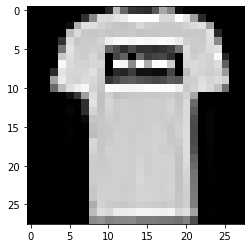

In [39]:
print("Number Equivalants:\n")
for idx,i in enumerate(training_data[0]):
    if training_data[1][idx] == 0:
        print(f"{clothing_list[training_data[1][idx]]}: ",training_data[1][idx])
        plt.imshow(i.reshape(28,28), cmap="gray")
        break

Number Equivalants:

Trouser:  1


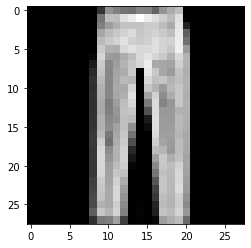

In [40]:
print("Number Equivalants:\n")
for idx,i in enumerate(training_data[0]):
    if training_data[1][idx] == 1:
        print(f"{clothing_list[training_data[1][idx]]}: ",training_data[1][idx])
        plt.imshow(i.reshape(28,28), cmap="gray")
        break

Number Equivalants:

Pullover:  2


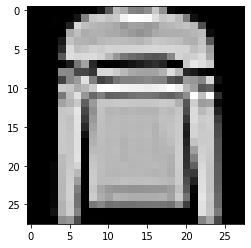

In [41]:
print("Number Equivalants:\n")
for idx,i in enumerate(training_data[0]):
    if training_data[1][idx] == 2:
        print(f"{clothing_list[training_data[1][idx]]}: ",training_data[1][idx])
        plt.imshow(i.reshape(28,28), cmap="gray")
        break

Number Equivalants:

Dress:  3


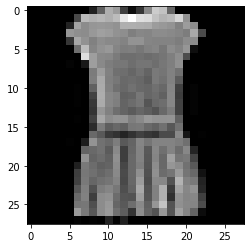

In [42]:
print("Number Equivalants:\n")
for idx,i in enumerate(training_data[0]):
    if training_data[1][idx] == 3:
        print(f"{clothing_list[training_data[1][idx]]}: ",training_data[1][idx])
        plt.imshow(i.reshape(28,28), cmap="gray")
        break

Number Equivalants:

Coat:  4


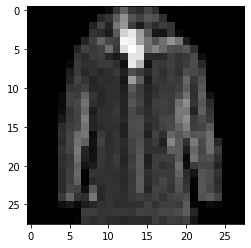

In [43]:
print("Number Equivalants:\n")
for idx,i in enumerate(training_data[0]):
    if training_data[1][idx] == 4:
        print(f"{clothing_list[training_data[1][idx]]}: ",training_data[1][idx])
        plt.imshow(i.reshape(28,28), cmap="gray")
        break

Number Equivalants:

T-shirt/top:  0


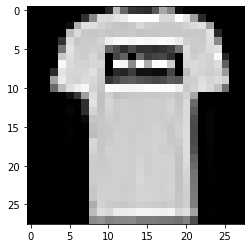

In [44]:
print("Number Equivalants:\n")
for idx,i in enumerate(training_data[0]):
    if training_data[1][idx] == 0:
        print(f"{clothing_list[training_data[1][idx]]}: ",training_data[1][idx])
        plt.imshow(i.reshape(28,28), cmap="gray")
        break

Number Equivalants:

Sandal:  5


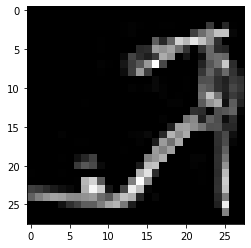

In [45]:
print("Number Equivalants:\n")
for idx,i in enumerate(training_data[0]):
    if training_data[1][idx] == 5:
        print(f"{clothing_list[training_data[1][idx]]}: ",training_data[1][idx])
        plt.imshow(i.reshape(28,28), cmap="gray")
        break

Number Equivalants:

Shirt:  6


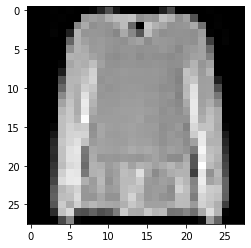

In [46]:
print("Number Equivalants:\n")
for idx,i in enumerate(training_data[0]):
    if training_data[1][idx] == 6:
        print(f"{clothing_list[training_data[1][idx]]}: ",training_data[1][idx])
        plt.imshow(i.reshape(28,28), cmap="gray")
        break

Number Equivalants:

Sneaker:  7


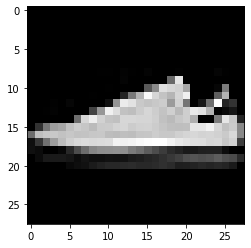

In [47]:
print("Number Equivalants:\n")
for idx,i in enumerate(training_data[0]):
    if training_data[1][idx] == 7:
        print(f"{clothing_list[training_data[1][idx]]}: ",training_data[1][idx])
        plt.imshow(i.reshape(28,28), cmap="gray")
        break

Number Equivalants:

Bag:  8


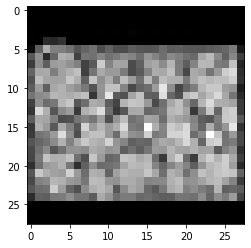

In [48]:
print("Number Equivalants:\n")
for idx,i in enumerate(training_data[0]):
    if training_data[1][idx] == 8:
        print(f"{clothing_list[training_data[1][idx]]}: ",training_data[1][idx])
        plt.imshow(i.reshape(28,28), cmap="gray")
        break

Number Equivalants:

Ankle boot:  9


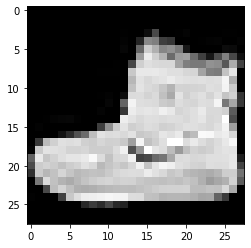

In [49]:
print("Number Equivalants:\n")
for idx,i in enumerate(training_data[0]):
    if training_data[1][idx] == 9:
        print(f"{clothing_list[training_data[1][idx]]}: ",training_data[1][idx])
        plt.imshow(i.reshape(28,28), cmap="gray")
        break

## Normalizing & Reshaping the Data 

In [64]:
from sklearn.preprocessing import MinMaxScaler
myscaler=MinMaxScaler()

In [65]:
scaled_training_data=myscaler.fit_transform(training_data[0])
scaled_test_data=myscaler.fit_transform(test_data[0])

Comparing Clothes Images of Before/After Normalizing

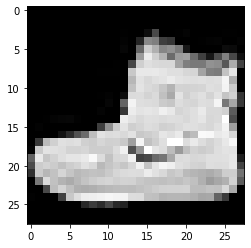

In [66]:
plt.imshow(training_data[0][0].reshape(28,28), cmap="gray")

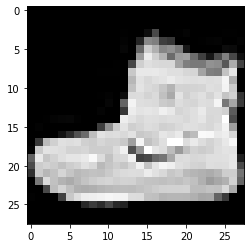

In [67]:
plt.imshow(scaled_training_data[0].reshape(28,28), cmap="gray")

Reshaping

In [68]:
len(scaled_training_data[0])

784

In [69]:
resized_training_data = []
resized_test_data = []

In [70]:
for i in range(len(training_data_std)):
    resized_training_data.append(scaled_training_data[i].reshape(28,28))
training_y = training_data[1][:]

In [71]:
for i in range(len(test_data_std)):
    resized_test_data.append(scaled_test_data[i].reshape(28,28))
test_y = test_data[1][:]

60.000 row, each one is 28x28

In [72]:
len(resized_training_data), len(training_y)

(60000, 60000)

In [73]:
len(resized_training_data[0])

28

In [74]:
len(resized_training_data[0][0])

28

10.000 row, each one is 28x28

In [75]:
len(resized_test_data), len(test_y)

(10000, 10000)

In [76]:
len(resized_test_data[0])

28

In [77]:
len(resized_test_data[0][0])

28

## K-NN Algorithm 

In [78]:
from sklearn.neighbors import KNeighborsClassifier

In [79]:
algorithm_knn=KNeighborsClassifier(n_neighbors=2, metric="minkowski", p=2)

Fit the dataset in form of 2-d array!

In [80]:
algorithm_knn.fit(scaled_training_data, training_y)

KNeighborsClassifier(n_neighbors=2)

In [81]:
algorithm_knn.predict(scaled_test_data)

array([9, 2, 1, ..., 8, 1, 5], dtype=uint8)

In [82]:
test_y

array([9, 2, 1, ..., 8, 1, 5], dtype=uint8)

In [84]:
algorithm_knn.score(scaled_test_data, test_y)

0.8455

Changing the neighbors

In [85]:
algorithm_knn_2=KNeighborsClassifier(n_neighbors=3, metric="minkowski", p=2)

In [86]:
algorithm_knn_2.fit(scaled_training_data, training_y)

KNeighborsClassifier(n_neighbors=3)

In [87]:
algorithm_knn_2.predict(scaled_test_data)

array([9, 2, 1, ..., 8, 1, 7], dtype=uint8)

In [88]:
test_y

array([9, 2, 1, ..., 8, 1, 5], dtype=uint8)

In [89]:
algorithm_knn_2.score(scaled_test_data, test_y)

0.8538

## Results of K-NN 

Importing the metrics

In [90]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

In [91]:
print("Accuracy", accuracy_score(test_y, algorithm_knn.predict(scaled_test_data)))
print("Recall", recall_score(test_y, algorithm_knn.predict(scaled_test_data),average="micro"))
print("Precision", precision_score(test_y, algorithm_knn.predict(scaled_test_data), average="micro"))
print("F1", f1_score(test_y, algorithm_knn.predict(scaled_test_data),average="micro"))

Accuracy 0.8455
Recall 0.8455
Precision 0.8455
F1 0.8455


In [92]:
(test_y!=algorithm_knn.predict(scaled_test_data)).sum()

1545

In [93]:
print("Accuracy", accuracy_score(test_y, algorithm_knn_2.predict(scaled_test_data)))
print("Recall", recall_score(test_y, algorithm_knn_2.predict(scaled_test_data),average="micro"))
print("Precision", precision_score(test_y, algorithm_knn_2.predict(scaled_test_data), average="micro"))
print("F1", f1_score(test_y, algorithm_knn_2.predict(scaled_test_data),average="micro"))

Accuracy 0.8538
Recall 0.8538
Precision 0.8538
F1 0.8538


In [94]:
(test_y!=algorithm_knn_2.predict(scaled_test_data)).sum()

1462

Confusion Matrix / n_neighbor = 2

In [95]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [96]:
cm=confusion_matrix(test_y, algorithm_knn.predict(scaled_test_data))

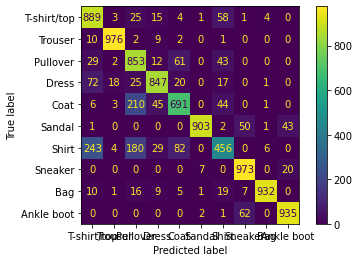

In [97]:
disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=clothing_list)
disp.plot()

Confusion Matrix / n_neighbor = 3

In [98]:
cm2=confusion_matrix(test_y, algorithm_knn_2.predict(scaled_test_data))

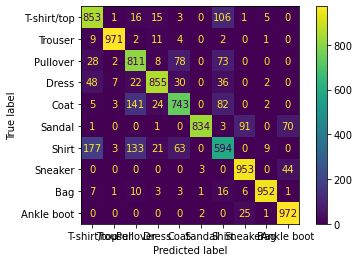

In [99]:
disp=ConfusionMatrixDisplay(confusion_matrix=cm2,display_labels=clothing_list)
disp.plot()

## Random Predictions of K-NN 

Random Prediction 1:

Random Prediction Number:  9287
Prediction:  [3]
Real:  3 Dress


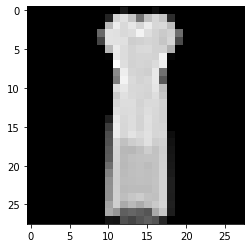

In [126]:
predict_num = np.random.randint(len(scaled_test_data)) ##random number
print("Random Prediction Number: ", predict_num)
print("Prediction: ", algorithm_knn.predict([scaled_test_data[predict_num]])) #predict
print("Real: ", test_y[predict_num], clothing_list[test_y[predict_num]]) #real
plt.imshow(scaled_test_data[predict_num].reshape(28,28), cmap="gray")

Random Prediction 2:

Random Prediction Number:  632
Prediction:  [2]
Real:  2 Pullover


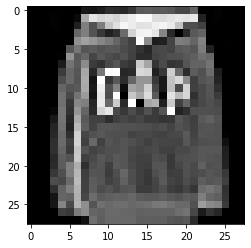

In [127]:
predict_num = np.random.randint(len(scaled_test_data)) ##random number
print("Random Prediction Number: ", predict_num)
print("Prediction: ", algorithm_knn.predict([scaled_test_data[predict_num]])) #predict
print("Real: ", test_y[predict_num], clothing_list[test_y[predict_num]]) #real
plt.imshow(scaled_test_data[predict_num].reshape(28,28), cmap="gray")

Random Prediction 3:

Random Prediction Number:  8622
Prediction:  [6]
Real:  6 Shirt


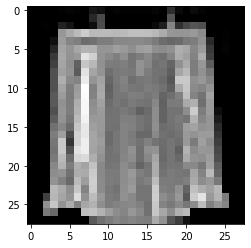

In [128]:
predict_num = np.random.randint(len(scaled_test_data)) ##random number
print("Random Prediction Number: ", predict_num)
print("Prediction: ", algorithm_knn.predict([scaled_test_data[predict_num]])) #predict
print("Real: ", test_y[predict_num], clothing_list[test_y[predict_num]]) #real
plt.imshow(scaled_test_data[predict_num].reshape(28,28), cmap="gray")

## SVM Algorithm 

In [100]:
from sklearn.svm import SVC

In [101]:
algorithm_svm=SVC(kernel="linear", C=0.1, random_state=0)

In [102]:
algorithm_svm.fit(scaled_training_data, training_y)

SVC(C=0.1, kernel='linear', random_state=0)

In [103]:
algorithm_svm.predict(scaled_test_data)

array([9, 2, 1, ..., 8, 1, 5], dtype=uint8)

In [104]:
test_y

array([9, 2, 1, ..., 8, 1, 5], dtype=uint8)

## Results of SVM

Importing the metrics

In [106]:
from sklearn.metrics import classification_report

In [107]:
print(classification_report(test_y, algorithm_svm.predict(scaled_test_data)))

              precision    recall  f1-score   support

           0       0.78      0.83      0.80      1000
           1       0.98      0.96      0.97      1000
           2       0.75      0.77      0.76      1000
           3       0.85      0.87      0.86      1000
           4       0.77      0.78      0.77      1000
           5       0.95      0.94      0.94      1000
           6       0.65      0.57      0.61      1000
           7       0.92      0.94      0.93      1000
           8       0.95      0.95      0.95      1000
           9       0.96      0.95      0.95      1000

    accuracy                           0.86     10000
   macro avg       0.85      0.86      0.85     10000
weighted avg       0.85      0.86      0.85     10000



In [125]:
algorithm_svm.score(scaled_test_data, test_y)

0.8557

In [129]:
print("Accuracy", accuracy_score(test_y, algorithm_svm.predict(scaled_test_data)))
print("Recall", recall_score(test_y, algorithm_svm.predict(scaled_test_data),average="micro"))
print("Precision", precision_score(test_y, algorithm_svm.predict(scaled_test_data), average="micro"))
print("F1", f1_score(test_y, algorithm_svm.predict(scaled_test_data),average="micro"))

Accuracy 0.8557
Recall 0.8557
Precision 0.8557
F1 0.8557


In [131]:
print("Misclassification: ", (test_y!=algorithm_svm.predict(scaled_test_data)).sum())

Misclassification:  1443


Confusion Matrix

In [130]:
cm_svm=confusion_matrix(test_y, algorithm_svm.predict(scaled_test_data))

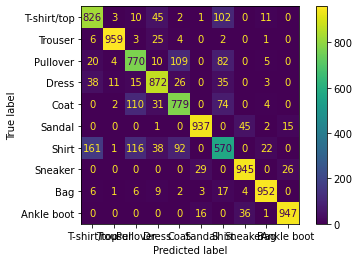

In [132]:
disp_svm=ConfusionMatrixDisplay(confusion_matrix=cm_svm,display_labels=clothing_list)
disp_svm.plot()

## Random Predictions of SVM

Random Prediction 1:

Random Prediction Number:  9852
Prediction:  [6]
Real:  2 Pullover


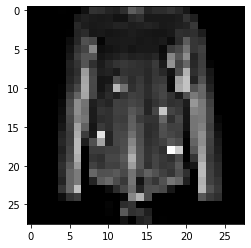

In [133]:
predict_num = np.random.randint(len(scaled_test_data)) ##random number
print("Random Prediction Number: ", predict_num)
print("Prediction: ", algorithm_svm.predict([scaled_test_data[predict_num]])) #predict
print("Real: ", test_y[predict_num], clothing_list[test_y[predict_num]]) #real
plt.imshow(scaled_test_data[predict_num].reshape(28,28), cmap="gray")

Random Prediction 2:

Random Prediction Number:  4097
Prediction:  [8]
Real:  8 Bag


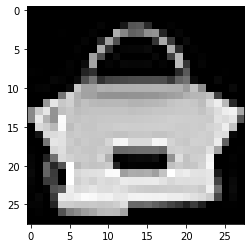

In [134]:
predict_num = np.random.randint(len(scaled_test_data)) ##random number
print("Random Prediction Number: ", predict_num)
print("Prediction: ", algorithm_svm.predict([scaled_test_data[predict_num]])) #predict
print("Real: ", test_y[predict_num], clothing_list[test_y[predict_num]]) #real
plt.imshow(scaled_test_data[predict_num].reshape(28,28), cmap="gray")

Random Prediction 3:

Random Prediction Number:  7075
Prediction:  [7]
Real:  7 Sneaker


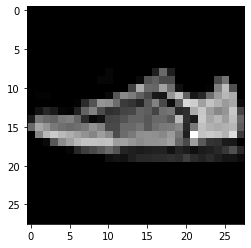

In [135]:
predict_num = np.random.randint(len(scaled_test_data)) ##random number
print("Random Prediction Number: ", predict_num)
print("Prediction: ", algorithm_svm.predict([scaled_test_data[predict_num]])) #predict
print("Real: ", test_y[predict_num], clothing_list[test_y[predict_num]]) #real
plt.imshow(scaled_test_data[predict_num].reshape(28,28), cmap="gray")

## Random Forest Algorithm

In [136]:
from sklearn.ensemble import RandomForestClassifier

In [137]:
algorithm_forest=RandomForestClassifier(criterion="entropy",n_estimators=100, max_depth=4, random_state=0)

In [139]:
algorithm_forest.fit(scaled_training_data, training_y)

RandomForestClassifier(criterion='entropy', max_depth=4, random_state=0)

In [140]:
algorithm_forest.predict(scaled_test_data)

array([9, 2, 1, ..., 8, 1, 7], dtype=uint8)

In [141]:
test_y

array([9, 2, 1, ..., 8, 1, 5], dtype=uint8)

## Results of Random Forest 

In [142]:
print("Accuracy", accuracy_score(test_y, algorithm_forest.predict(scaled_test_data)))
print("Recall", recall_score(test_y, algorithm_forest.predict(scaled_test_data),average="micro"))
print("Precision", precision_score(test_y, algorithm_forest.predict(scaled_test_data), average="micro"))
print("F1", f1_score(test_y, algorithm_forest.predict(scaled_test_data),average="micro"))
print("Misclassification: ", (test_y!=algorithm_forest.predict(scaled_test_data)).sum())

Accuracy 0.7393
Recall 0.7393
Precision 0.7393
F1 0.7393
Misclassification:  2607


In [143]:
print(classification_report(test_y, algorithm_forest.predict(scaled_test_data)))

              precision    recall  f1-score   support

           0       0.74      0.78      0.76      1000
           1       0.98      0.85      0.91      1000
           2       0.55      0.72      0.62      1000
           3       0.64      0.89      0.74      1000
           4       0.51      0.68      0.58      1000
           5       0.98      0.72      0.83      1000
           6       0.33      0.01      0.01      1000
           7       0.80      0.89      0.84      1000
           8       0.91      0.92      0.91      1000
           9       0.82      0.94      0.87      1000

    accuracy                           0.74     10000
   macro avg       0.72      0.74      0.71     10000
weighted avg       0.72      0.74      0.71     10000



Confusion Matrix

In [144]:
cm_forest=confusion_matrix(test_y, algorithm_forest.predict(scaled_test_data))

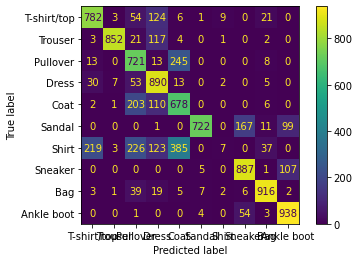

In [145]:
disp_svm=ConfusionMatrixDisplay(confusion_matrix=cm_forest,display_labels=clothing_list)
disp_svm.plot()

## Random Predictions of Random Forest

Random Prediction 1:

Random Prediction Number:  6776
Prediction:  [2]
Real:  2 Pullover


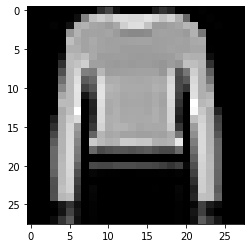

In [146]:
predict_num = np.random.randint(len(scaled_test_data)) ##random number
print("Random Prediction Number: ", predict_num)
print("Prediction: ", algorithm_forest.predict([scaled_test_data[predict_num]])) #predict
print("Real: ", test_y[predict_num], clothing_list[test_y[predict_num]]) #real
plt.imshow(scaled_test_data[predict_num].reshape(28,28), cmap="gray")

Random Prediction 2:

Random Prediction Number:  25
Prediction:  [2]
Real:  4 Coat


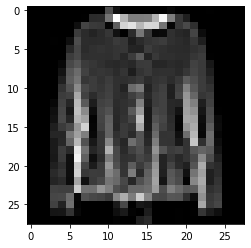

In [148]:
predict_num = np.random.randint(len(scaled_test_data)) ##random number
print("Random Prediction Number: ", predict_num)
print("Prediction: ", algorithm_forest.predict([scaled_test_data[predict_num]])) #predict
print("Real: ", test_y[predict_num], clothing_list[test_y[predict_num]]) #real
plt.imshow(scaled_test_data[predict_num].reshape(28,28), cmap="gray")

Random Prediction 3:

Random Prediction Number:  8859
Prediction:  [4]
Real:  6 Shirt


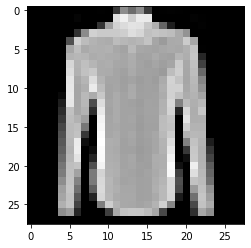

In [149]:
predict_num = np.random.randint(len(scaled_test_data)) ##random number
print("Random Prediction Number: ", predict_num)
print("Prediction: ", algorithm_forest.predict([scaled_test_data[predict_num]])) #predict
print("Real: ", test_y[predict_num], clothing_list[test_y[predict_num]]) #real
plt.imshow(scaled_test_data[predict_num].reshape(28,28), cmap="gray")

## Conclusion

Conclusion Table:

In [150]:
conc_dict = {"Algorithm":["K-NN(nn=2)","K-NN(nn=3)","SVM","Random Forest"],
            "Accuracy":[accuracy_score(test_y, algorithm_knn.predict(scaled_test_data)),accuracy_score(test_y, algorithm_knn_2.predict(scaled_test_data)),accuracy_score(test_y, algorithm_svm.predict(scaled_test_data)),accuracy_score(test_y, algorithm_forest.predict(scaled_test_data))],
            "Recall":[recall_score(test_y, algorithm_knn.predict(scaled_test_data),average="micro"),recall_score(test_y, algorithm_knn_2.predict(scaled_test_data),average="micro"),recall_score(test_y, algorithm_svm.predict(scaled_test_data),average="micro"),recall_score(test_y, algorithm_forest.predict(scaled_test_data),average="micro")],
            "Precision":[precision_score(test_y, algorithm_knn.predict(scaled_test_data), average="micro"),precision_score(test_y, algorithm_knn_2.predict(scaled_test_data), average="micro"),precision_score(test_y, algorithm_svm.predict(scaled_test_data), average="micro"),precision_score(test_y, algorithm_forest.predict(scaled_test_data), average="micro")],
            "F1":[f1_score(test_y, algorithm_knn.predict(scaled_test_data),average="micro"),f1_score(test_y, algorithm_knn_2.predict(scaled_test_data),average="micro"),f1_score(test_y, algorithm_svm.predict(scaled_test_data),average="micro"),f1_score(test_y, algorithm_forest.predict(scaled_test_data),average="micro")],
            "Misclassification":[(test_y!=algorithm_knn.predict(scaled_test_data)).sum(),(test_y!=algorithm_knn_2.predict(scaled_test_data)).sum(),(test_y!=algorithm_svm.predict(scaled_test_data)).sum(),(test_y!=algorithm_forest.predict(scaled_test_data)).sum()]}

In [152]:
conclusion_df = pd.DataFrame(conc_dict)

In [153]:
conclusion_df

,Algorithm,Accuracy,Recall,Precision,F1,Misclassification
0,K-NN(nn=2),0.8455,0.8455,0.8455,0.8455,1545
1,K-NN(nn=3),0.8538,0.8538,0.8538,0.8538,1462
2,SVM,0.8557,0.8557,0.8557,0.8557,1443
3,Random Forest,0.7393,0.7393,0.7393,0.7393,2607
